# GPS Logger program kimenetéből közelítő x, y és t adatok számolása

## Fizika informatikusoknak géptermi gyakorlat

v 2026/0.95

In [1]:
import numpy as np    # NumPy
import pandas as pd   # Pandas, csak a CSV olvasás miatt
%matplotlib inline    
import matplotlib.pyplot as plt # MatPlotLib

Ez a függvény a "GPS Logger" program által exportált CSV fájlokból kikeresi az idő- és helykoordinátákat, és ezeket átkonvertálja x, y, t adatokká:
   * t az abszolút idő helyett az első adatponttól mért idő (másodpercben)
   * x, y: a Föld felszínéhez a pálya közelében fektetett érintősíkra kivetített kordináták: x: keletre mutató, y: északra mutató (méterben)

A közölt módszer egyszerű, de kicsit pontatlan: 
   1) a Földet pontosan gömb alakúnak tételezi fel
   2) a síkra való vetítés pontatlan lesz, ha a pálya méretek összevethetők a Föld sugarával
   
Modellhiba: 500 km-nél kisebb pályaméret esetében 1% alatti.

Ez csak egy tutorial fájl a GPS adatok kezeléséről. Komoly munkához ezt a korábbi kinematikai rutinokkal együtt kell alkalmazni és simítani kell a bemenő adatokat.

# Ismerkedés a GPS fájl tartalmával

Az Android-os "GPS Logger" applikáció CSV kimenetét használjuk. Más program esetleg más oszlopokat vagy más sorrendben ad ki.

In [2]:
# beolvasás a Pandas eljárásával
data=pd.read_csv('seta-1.txt',sep=',')

# Milyen oszlopok vannak?
print("Oszlopnevek:")
print(data.columns.to_list())

# áttekintés
print("\n\nÁttekintés:")
print(data.describe)

Oszlopnevek:
['type', 'date time', 'latitude', 'longitude', 'accuracy(m)', 'altitude(m)', 'geoid_height(m)', 'speed(m/s)', 'bearing(deg)', 'sat_used', 'sat_inview', 'name', 'desc']


Áttekintés:
<bound method NDFrame.describe of     type            date time   latitude  longitude  accuracy(m)  altitude(m)  \
0      T  2021-10-09 07:01:33  47.675754  17.646944            4      112.104   
1      T  2021-10-09 07:01:34  47.675749  17.646944            4      112.827   
2      T  2021-10-09 07:01:35  47.675748  17.646944            4      112.858   
3      T  2021-10-09 07:01:36  47.675748  17.646944            4      112.867   
4      T  2021-10-09 07:01:37  47.675744  17.646948            4      113.999   
..   ...                  ...        ...        ...          ...          ...   
142    T  2021-10-09 07:03:55  47.675761  17.646990            5      115.865   
143    T  2021-10-09 07:03:56  47.675764  17.646961            6      116.477   
144    T  2021-10-09 07:03:57  47.675763  

# GPS_Logger_to_xyt 

In [3]:
def GPS_Logger_to_xyt(fname, orig='first'):
    """Az 'orig'-ban specifikáltaknak megfelelő origót használva érintősíkra vetíti a GPS koordinátákat
        az 'fname' fájlból. A Földet gömb alakkal közelíti."""
    
    # CSV beolvasás
    data=pd.read_csv(fname,sep=',')
    
    # szélességből és hosszúságból közelítő x-y-t számol
    long=np.radians(data.longitude.values)
    lat=np.radians(data.latitude.values)

    # origó beállítása
    if orig=='first':   # origó=első beolvasott pont
        long_0=long[0]
        lat_0=lat[0]
    elif orig=='center': # origó=pontog koordinátáinak átlagából
        long_0=long.mean()
        lat_0=lat.mean()
    else:
        print("Érvénytelen origó definíció.")
        return

    # Közelítő számítás: kis a Föld sugaránál sokkal kisebb pályaméretre közel igaz.
    R_F=6378000.0 # a Föld sugara m-ben
    x=(long-long_0)*np.cos(lat_0)*R_F
    y=(lat-lat_0)*R_F

    # Az időpontokat az indulástól, másodpercben számolja
    tdat=pd.to_datetime(data['date time'], format="%Y-%m-%d %H:%M:%S").to_numpy()
    t=(tdat-tdat[0])/np.timedelta64(1, 's')  

    # Pontosság kicsomagolása
    acc=data['accuracy(m)'].values

    return t, x, y, acc

In [4]:
def print_main_params(t, x, y, acc):

    print("Mérési pontok száma   : %d"%(len(t)))

    delta_t=t[-1]-t[0]
    print("Időtartam             : %.2f s"%(delta_t))

    delta_x=x[-1]-x[0]
    delta_y=y[-1]-y[0]
    print("Elmozdulás-komponensek: %.2f m, %.2f m"%(delta_x, delta_y))

    delta_r_abs=(delta_x**2+delta_y**2)**0.5   # Pitagorasz-tétel
    print("Elmozdulás nagysága   : %.2f m"%(delta_r_abs))
    print("Átlagsebesség-komponensek: %.2f m/s, %.2f m/s"%(delta_x/delta_t, delta_y/delta_t))
    print("Átlagsebesség nagysága   : %.2f m/s"%(delta_r_abs/delta_t))

    print("Átlag pontosság          : %.2f m"%(acc.mean()))

## Példa: séta

### Beolvasás

In [5]:
t, x, y, acc=GPS_Logger_to_xyt('seta-1.txt', orig='first')

In [6]:
print_main_params(t, x, y, acc)

Mérési pontok száma   : 147
Időtartam             : 146.00 s
Elmozdulás-komponensek: -3.02 m, -0.67 m
Elmozdulás nagysága   : 3.09 m
Átlagsebesség-komponensek: -0.02 m/s, -0.00 m/s
Átlagsebesség nagysága   : 0.02 m/s
Átlag pontosság          : 5.26 m


### Egyszerű megjelenítés

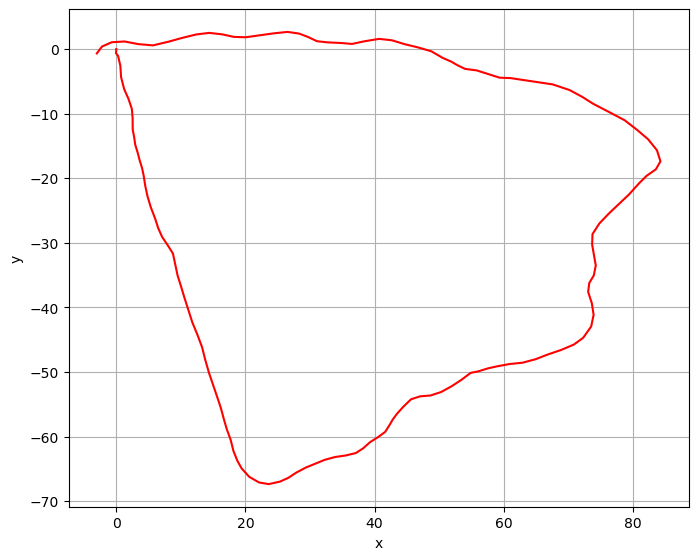

In [7]:
fig=plt.figure(figsize=(8,8))
ax1=fig.add_subplot(111) 
ax1.set_xlabel("x")
ax1.set_ylabel("y")

ax1.plot(x, y, color="red") 

ax1.grid()
ax1.set_aspect('equal')

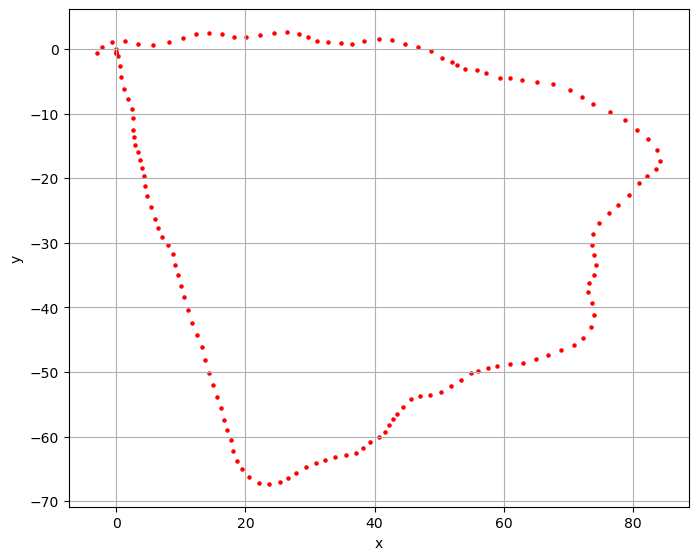

In [8]:
fig=plt.figure(figsize=(8,8)) 
ax1=fig.add_subplot(111) 
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# scatter: pontok kirajtolása összekötés helyett
ax1.scatter(x, y, color="red", s=5) 

ax1.grid()
ax1.set_aspect('equal')

A scatter-ből látszik a mozgás sebessége. Az is érződik, hogy a mozgás valószínűleg nem volt ennyire imbolygó.

## Példa: busz

In [9]:
tb, xb, yb, accb=GPS_Logger_to_xyt('busz-1.txt', orig='center')
print_main_params(tb, xb, yb, accb)

Mérési pontok száma   : 609
Időtartam             : 608.00 s
Elmozdulás-komponensek: 1510.03 m, -2939.90 m
Elmozdulás nagysága   : 3305.03 m
Átlagsebesség-komponensek: 2.48 m/s, -4.84 m/s
Átlagsebesség nagysága   : 5.44 m/s
Átlag pontosság          : 4.91 m


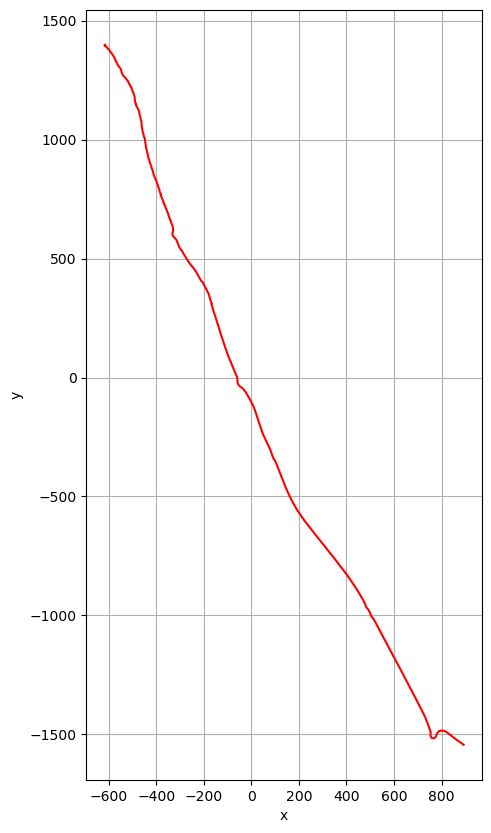

In [10]:
# teljes pályagörbe
fig=plt.figure(figsize=(10,10))  
ax1=fig.add_subplot(111) 
ax1.set_xlabel("x")
ax1.set_ylabel("y")

ax1.plot(xb, yb, color="red") 

ax1.grid()
ax1.set_aspect('equal')

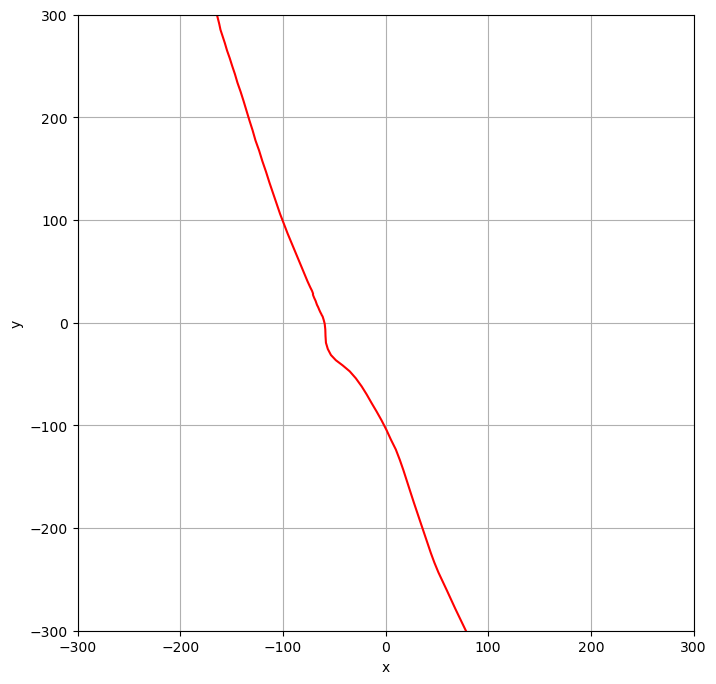

In [11]:
# egy tartomány pályagörbéje:
fig=plt.figure(figsize=(8,8))  # rajzméret
ax1=fig.add_subplot(111) 
ax1.set_xlabel("x")
ax1.set_ylabel("y")

ax1.plot(xb, yb, color="red") 

# itt jelöljük ki a tartományt:
ax1.set_xlim([-300, +300])
ax1.set_ylim([-300, +300])
ax1.grid()
ax1.set_aspect('equal')

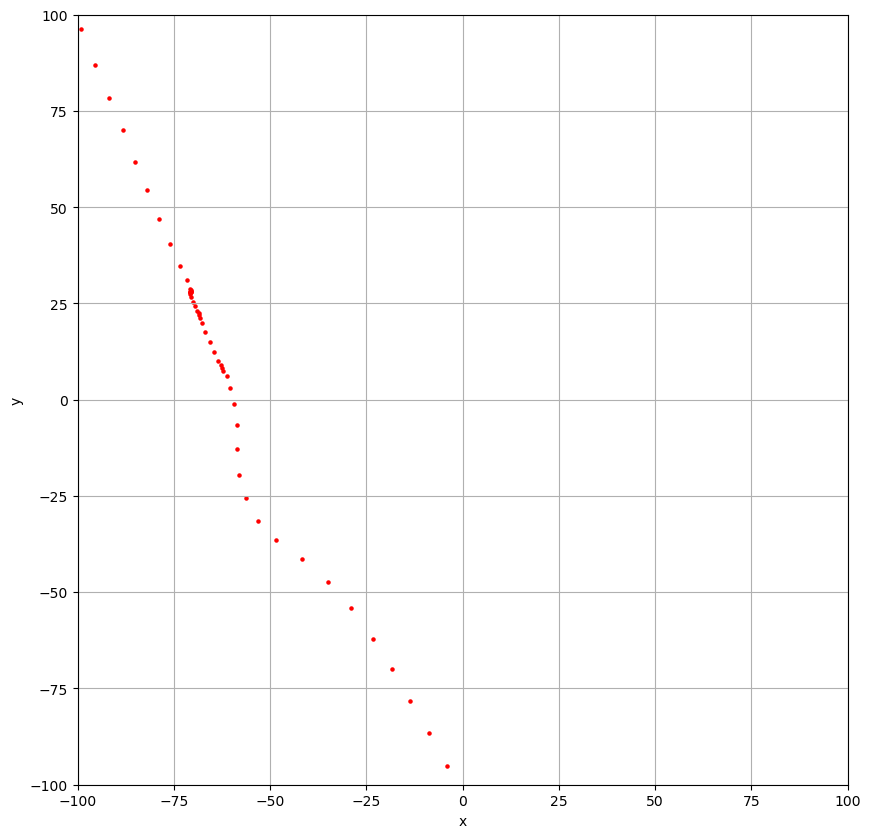

In [12]:
# egy tartomány mérési pontjai
fig=plt.figure(figsize=(10,10))  # rajzméret
ax1=fig.add_subplot(111) 
ax1.set_xlabel("x")
ax1.set_ylabel("y")

ax1.scatter(xb, yb, color="red", s=5) 

ax1.set_xlim([-100, +100])
ax1.set_ylim([-100, +100])
ax1.grid()
ax1.set_aspect('equal')

In [13]:
# Milyen közlekedési szituációt ábrázol ez a plot?